In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [56]:
df = pd.read_csv("m31_rotation_curve.csv")


In [57]:
df.head()

,R,R_error,Vc,Vc_error,fitted_Vc
0,0.22,0.10,163.24,15.61,175.78
1,0.65,0.19,210.95,18.56,220.61
2,1.86,0.02,223.80,10.72,223.43
3,3.19,0.02,226.79,7.96,220.33
4,4.23,0.02,213.74,8.17,221.38


In [58]:
df.tail()

,R,R_error,Vc,Vc_error,fitted_Vc
37,52.08,1.63,182.05,38.15,199.23
38,54.85,1.67,196.28,38.81,198.33
39,67.26,14.95,202.02,40.67,194.47
40,98.74,17.19,192.59,42.23,185.55
41,123.56,11.60,168.53,41.34,179.31


In [59]:
G = 4.3009e-6   #gravitational constant
df["Mass_enclosed"] =(df["Vc"]**2 * df["R"])/G

M_luminous = 1.17594e11
M_total = df["Mass_enclosed"].max()

M_dark = M_total - M_luminous
print(f"Total Mass of M31       = {M_total:.3e} Msun")
print(f"Luminous Mass of M31    = {M_luminous:.3e} Msun")
print(f"Dark Matter Mass of M31 = {M_dark:.3e} Msun")

Total Mass of M31       = 8.515e+11 Msun
Luminous Mass of M31    = 1.176e+11 Msun
Dark Matter Mass of M31 = 7.339e+11 Msun


In [64]:
df["Component"]= "temp"
df.loc[0:1,"Component"]="Bulge"
df.loc[2:21,"Component"]="Disk"
df.loc[22:, "Component"]="Halo"


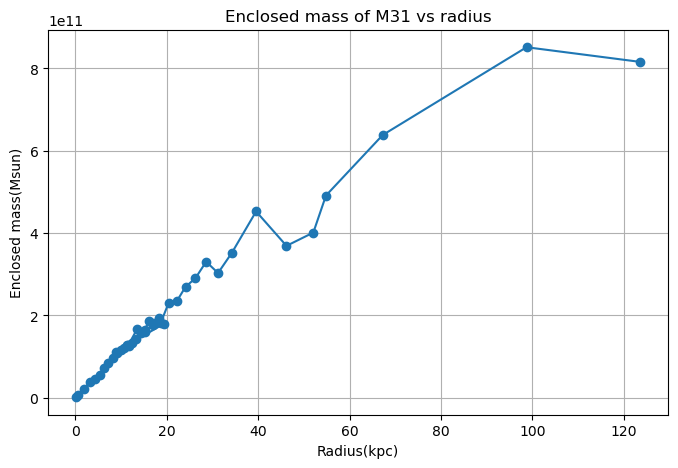

In [61]:
plt.figure(figsize=(8,5))
plt.plot(df["R"],df["Mass_enclosed"],marker= 'o')
plt.xlabel("Radius(kpc)")
plt.ylabel("Enclosed mass(Msun)")
plt.title("Enclosed mass of M31 vs radius")
plt.grid(True)
plt.show()


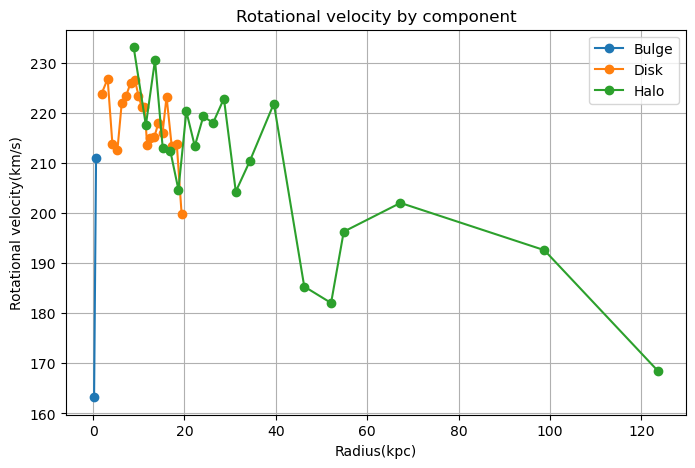

In [62]:
plt.figure(figsize=(8,5))
for comp in ["Bulge","Disk","Halo"]:
    subset =df[df["Component"]==comp]
    plt.plot(subset["R"],subset["Vc"],marker='o',label=comp)
plt.grid(True)


plt.xlabel("Radius(kpc)")
plt.ylabel("Rotational velocity(km/s)")
plt.title("Rotational velocity by component")
plt.legend()
plt.show()


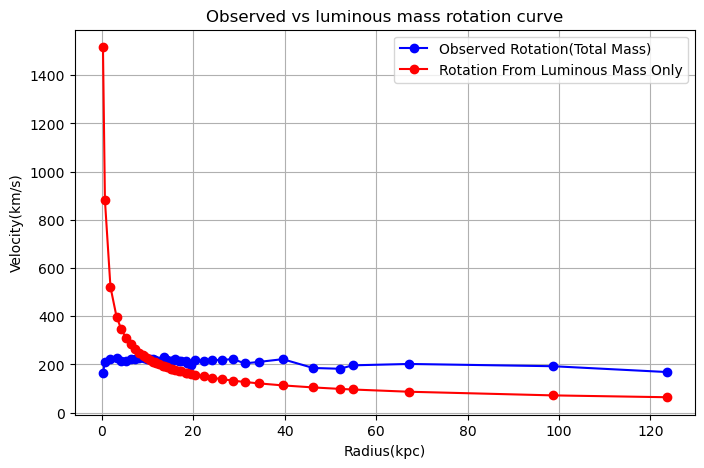

In [63]:
df["Vc_luminous"] = np.sqrt(G * M_luminous / df["R"])

plt.figure(figsize=(8,5))
plt.grid(True)
plt.plot(df["R"],df["Vc"],marker='o', label="Observed Rotation(Total Mass)",color='blue')
plt.plot(df["R"],df["Vc_luminous"],marker='o',label= "Rotation From Luminous Mass Only", color='red')
plt.xlabel("Radius(kpc)")
plt.ylabel("Velocity(km/s)")
plt.title("Observed vs luminous mass rotation curve")
plt.legend()
plt.show()
